---
## ✏️ Step 7: 도전 과제

### 🟢 기초
1. `batch_size`를 32, 128로 바꿔서 학습 속도와 정확도를 비교해보세요.
2. `Dropout` 비율을 0.3, 0.7로 변경해보세요. 과적합이 줄어드나요?

### 🟡 중급
3. Conv Layer를 하나 더 추가해보세요 (64→128 채널).
4. `BatchNorm2d`를 제거했을 때 학습이 어떻게 달라지나요?
5. 데이터 증강 (`RandomRotation`, `RandomAffine`)을 추가해보세요.

### 🔴 심화
6. 7-Segment 모델과 MNIST 모델의 정확도를 같은 그래프에 그려 비교하세요.
7. `torch.onnx.export()`로 모델을 ONNX 형식으로 저장해보세요.
8. Fashion-MNIST로 같은 모델을 학습하면 정확도가 어떻게 되나요?

In [1]:
# ✏️ 여기에 도전 과제 코드를 작성하세요!

# 예시: Fashion-MNIST 로드
# fashion_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
# fashion_test  = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
# ... (동일한 모델 구조로 학습)

print('도전 과제를 직접 구현해보세요! 🚀')


# 환경 설정
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 재현성 시드
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device : {device}')

# 한글 폰트 설정(추가 입력)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ─── 전처리 정의 ─────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지(0-255)를 파이토치 텐서(0.0-1.0)로 변환
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 공식 통계값(평균, 표준편차)으로 데이터 표준화
])

# ─── 데이터셋 다운로드 & 로드 ─────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print(f'학습 데이터: {len(train_dataset):,}개')
print(f'테스트 데이터: {len(test_dataset):,}개')
print(f'이미지 크기: {train_dataset[0][0].shape}  (채널×높이×너비)')
print(f'클래스: {train_dataset.classes}')

도전 과제를 직접 구현해보세요! 🚀
PyTorch: 2.6.0+cu124
Device : cuda
학습 데이터: 60,000개
테스트 데이터: 10,000개
이미지 크기: torch.Size([1, 28, 28])  (채널×높이×너비)
클래스: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [2]:
# CNN 모델 정의하기 
class MnistCNN(nn.Module):
    """
    MNIST 손글씨 분류를 위한 CNN 모델
    
    Architecture:
        Conv Block 1: Conv(1→32) → BN → ReLU → MaxPool
        Conv Block 2: Conv(32→64) → BN → ReLU → MaxPool
        Classifier:   FC(1600→128) →  ReLU → Dropout → FC(128→10)
    """
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN, self).__init__()

        # ── 합성곱 블록 1 ──────────────────────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, padding=1),  # 1×28×28 → 32×28×28
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×28×28 → 32×14×14
        )

        # ── 합성곱 블록 2 ──────────────────────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),  # 32×14×14 → 64×14×14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64×14×14 → 64×7×7
        )

        # ── 완전연결 분류기 ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),             # 64×7×7 = 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # Conv Block 1
        x = self.conv_block2(x)   # Conv Block 2
        x = self.classifier(x)   # Classifier
        return x                  # raw logits (CrossEntropyLoss 사용)

    def get_feature_maps(self, x):
        """Feature Map 시각화를 위해 중간 출력 반환"""
        feat1 = self.conv_block1(x)
        feat2 = self.conv_block2(feat1)
        return feat1, feat2


model = MnistCNN(dropout_rate=0.5).to(device)
print(model)

# 에폭, 평가 함수 정의
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에폭 학습 함수."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """평가 함수. (그래디언트 계산 없음)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


MnistCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)



🚀 실험 시작: BATCH_SIZE = 32
Epoch [ 1/15] Train Acc: 92.77% | Test Acc: 98.51%
Epoch [ 5/15] Train Acc: 98.07% | Test Acc: 99.26%
Epoch [10/15] Train Acc: 99.15% | Test Acc: 99.25%
Epoch [15/15] Train Acc: 99.53% | Test Acc: 99.36%

✅ BATCH_SIZE 32 학습 완료! 소요 시간: 279.53초

🚀 실험 시작: BATCH_SIZE = 64
Epoch [ 1/15] Train Acc: 93.78% | Test Acc: 98.37%
Epoch [ 5/15] Train Acc: 98.41% | Test Acc: 99.13%
Epoch [10/15] Train Acc: 99.26% | Test Acc: 99.26%
Epoch [15/15] Train Acc: 99.61% | Test Acc: 99.36%

✅ BATCH_SIZE 64 학습 완료! 소요 시간: 262.26초

🚀 실험 시작: BATCH_SIZE = 128
Epoch [ 1/15] Train Acc: 92.78% | Test Acc: 97.98%
Epoch [ 5/15] Train Acc: 98.25% | Test Acc: 99.06%
Epoch [10/15] Train Acc: 99.05% | Test Acc: 99.21%
Epoch [15/15] Train Acc: 99.43% | Test Acc: 99.28%

✅ BATCH_SIZE 128 학습 완료! 소요 시간: 241.09초


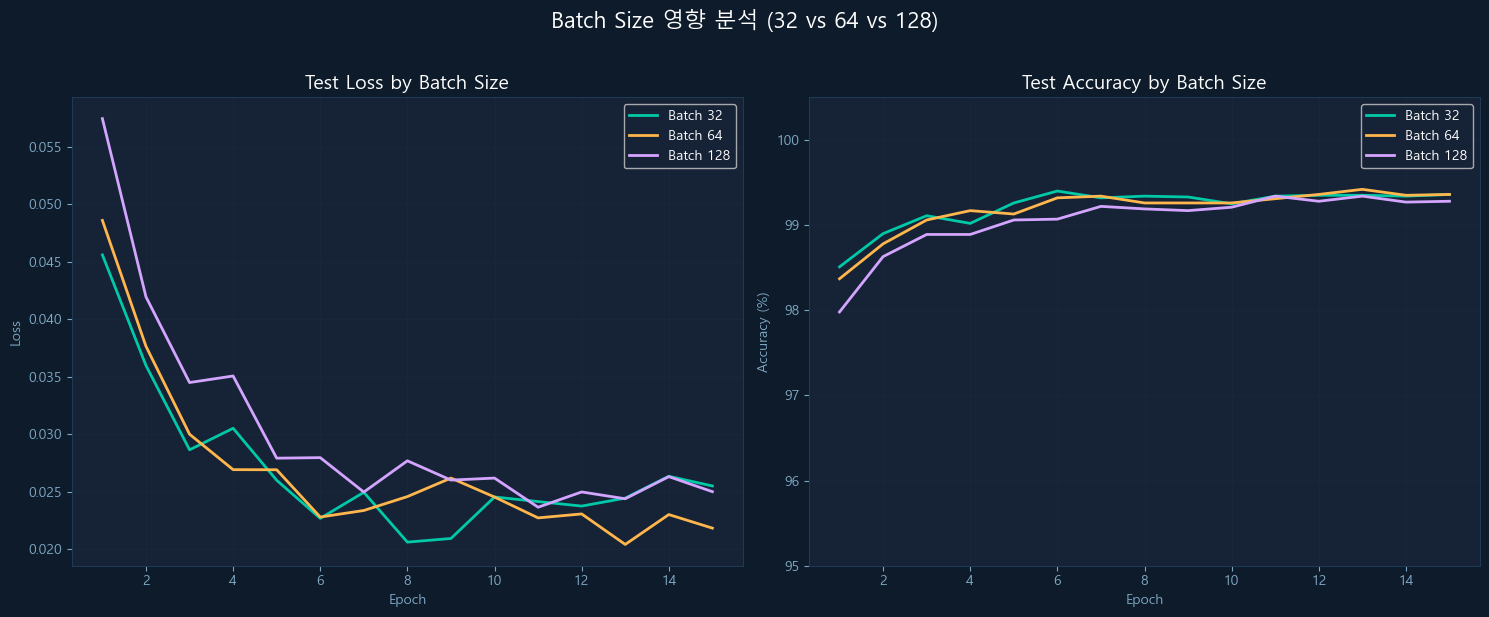


  Batch Size |   Total Time |  Avg Time/Epoch | Final Accuracy
------------------------------------------------------------
          32 |      279.53s |          18.64s |       99.36%
          64 |      262.26s |          17.48s |       99.36%
         128 |      241.09s |          16.07s |       99.28%


In [3]:
# # 1. 배치사이즈 32, 128로 바꾸기 / 드롭아웃 비율 0.3, 0.7로 변경하기
# 1-1 배치사이즈 32, 128로 변경하여 학습속도와 정확도 비교하기
import time # 학습 시간 측성용

# ─── 실험 설정 ────────────────────────────────────────────────────────────
batch_sizes = [32, 64, 128]
results = {} # 결과를 저장할 딕셔너리

for bs in batch_sizes:
    print(f'\n' + '='*60)
    print(f'🚀 실험 시작: BATCH_SIZE = {bs}')
    print('='*60)
    
    # 1. DataLoader 재설정
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    
    # 2. 모델 및 옵티마이저 초기화 (매 실험마다 초기화 필수)
    model = MnistCNN(dropout_rate=0.5).to(device)
    NUM_EPOCHS    = 15
    LEARNING_RATE = 0.001
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    start_time = time.time() # 시간 측정 시작
    
    # 3. 학습 루프
    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>2}/{NUM_EPOCHS}] Train Acc: {tr_acc*100:.2f}% | Test Acc: {te_acc*100:.2f}%')
            
    end_time = time.time() # 시간 측정 종료
    duration = end_time - start_time
    
    # 결과 저장
    results[bs] = {
        'history': history,
        'duration': duration,
        'final_acc': history['test_acc'][-1]
    }
    
    print(f'\n✅ BATCH_SIZE {bs} 학습 완료! 소요 시간: {duration:.2f}초')

# ─── 시각화 및 결과 비교 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1b2a')
epochs_range = range(1, NUM_EPOCHS + 1)

# 배치 사이즈별 색상 설정
colors = {32: '#00c9a7', 64: '#ffb74d', 128: '#d4a5ff'}

for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# [좌측] 테스트 손실 곡선 비교
for bs in batch_sizes:
    axes[0].plot(epochs_range, results[bs]['history']['test_loss'], 
                 color=colors[bs], lw=2, label=f'Batch {bs}')
axes[0].set_title('Test Loss by Batch Size', color='white', fontsize=14)
axes[0].set_ylabel('Loss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')

# [우측] 테스트 정확도 곡선 비교
for bs in batch_sizes:
    axes[1].plot(epochs_range, [a*100 for a in results[bs]['history']['test_acc']], 
                 color=colors[bs], lw=2, label=f'Batch {bs}')
axes[1].set_title('Test Accuracy by Batch Size', color='white', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(95, 100.5) # 차이를 보기 위해 범위 좁힘
axes[1].legend(facecolor='#162236', labelcolor='white')

plt.suptitle('Batch Size 영향 분석 (32 vs 64 vs 128)', color='white', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ─── 최종 결과 요약 출력 ──────────────────────────────────────────────────
print(f'\n' + '='*60)
print(f'{"Batch Size":>12} | {"Total Time":>12} | {"Avg Time/Epoch":>15} | {"Final Accuracy":>12}')
print('-'*60)
for bs in batch_sizes:
    data = results[bs]
    print(f'{bs:>12} | {data["duration"]:>11.2f}s | {data["duration"]/NUM_EPOCHS:>14.2f}s | {data["final_acc"]*100:>11.2f}%')
print('='*60)



🚀 실험 시작: Dropout Rate = 0.3
Epoch [ 1/15] Train Acc: 95.37% | Test Acc: 98.48%
Epoch [ 5/15] Train Acc: 98.82% | Test Acc: 99.16%
Epoch [10/15] Train Acc: 99.64% | Test Acc: 99.16%
Epoch [15/15] Train Acc: 99.85% | Test Acc: 99.30%

🚀 실험 시작: Dropout Rate = 0.5
Epoch [ 1/15] Train Acc: 93.39% | Test Acc: 98.65%
Epoch [ 5/15] Train Acc: 98.13% | Test Acc: 98.98%
Epoch [10/15] Train Acc: 99.07% | Test Acc: 99.27%
Epoch [15/15] Train Acc: 99.47% | Test Acc: 99.34%

🚀 실험 시작: Dropout Rate = 0.7
Epoch [ 1/15] Train Acc: 81.91% | Test Acc: 98.04%
Epoch [ 5/15] Train Acc: 91.73% | Test Acc: 98.90%
Epoch [10/15] Train Acc: 94.63% | Test Acc: 99.00%
Epoch [15/15] Train Acc: 95.54% | Test Acc: 99.14%


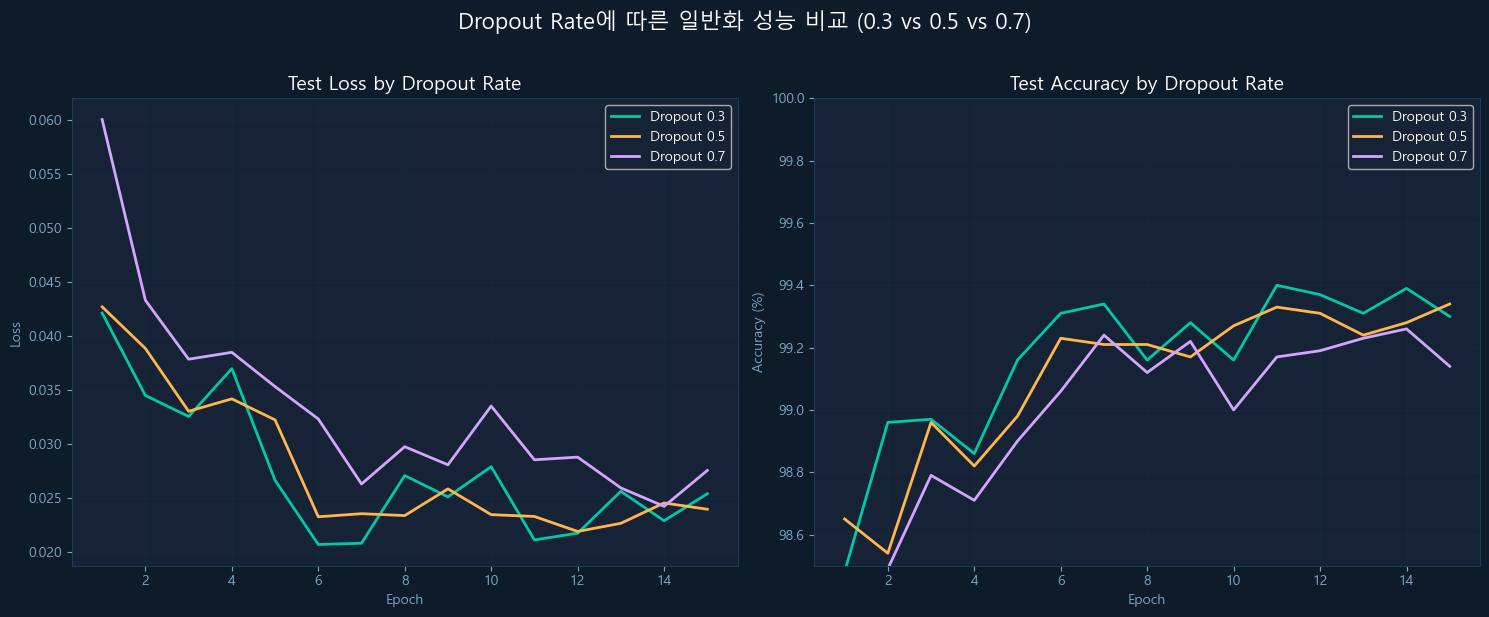


Dropout Rate |    Train Acc |     Test Acc |    Overfitting Gap
---------------------------------------------------------------------------
         0.3 |       99.85% |       99.30% |              0.55%
         0.5 |       99.47% |       99.34% |              0.13%
         0.7 |       95.54% |       99.14% |              3.60%
※ Overfitting Gap이 작을수록 모델의 일반화 성능이 뛰어나다고 판단할 수 있습니다.


In [4]:
# ─── 실험 설정 (Dropout Rate 비교) ──────────────────────────────────────────
dropout_rates = [0.3, 0.5, 0.7]
results = {}

# DataLoader 고정
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

for dr in dropout_rates:
    print(f'\n' + '='*60)
    print(f'🚀 실험 시작: Dropout Rate = {dr}')
    print('='*60)
    
    # 1. 모델 초기화 (드롭아웃 비율 적용)
    model = MnistCNN(dropout_rate=dr).to(device)
    NUM_EPOCHS    = 15
    LEARNING_RATE = 0.001
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    # 2. 학습 루프
    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>2}/{NUM_EPOCHS}] Train Acc: {tr_acc*100:.2f}% | Test Acc: {te_acc*100:.2f}%')
            
    # 결과 저장
    results[dr] = {
        'history': history,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'gap': abs(history['train_acc'][-1] - history['test_acc'][-1]) # 과적합 격차 지표
    }

# ─── 시각화 및 결과 비교 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1b2a')
epochs_range = range(1, NUM_EPOCHS + 1)

# 드롭아웃 비율별 색상 설정
colors = {0.3: '#00c9a7', 0.5: '#ffb74d', 0.7: '#d4a5ff'}

for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# [좌측] 테스트 손실 곡선 비교
for dr in dropout_rates:
    axes[0].plot(epochs_range, results[dr]['history']['test_loss'], 
                 color=colors[dr], lw=2, label=f'Dropout {dr}')
axes[0].set_title('Test Loss by Dropout Rate', color='white', fontsize=14)
axes[0].set_ylabel('Loss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')

# [우측] 테스트 정확도 곡선 비교
for dr in dropout_rates:
    axes[1].plot(epochs_range, [a*100 for a in results[dr]['history']['test_acc']], 
                 color=colors[dr], lw=2, label=f'Dropout {dr}')
axes[1].set_title('Test Accuracy by Dropout Rate', color='white', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(98.5, 100) # 미세한 성능 차이를 위해 범위 조정
axes[1].legend(facecolor='#162236', labelcolor='white')

plt.suptitle('Dropout Rate에 따른 일반화 성능 비교 (0.3 vs 0.5 vs 0.7)', color='white', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ─── 최종 결과 요약 출력 ──────────────────────────────────────────────────
print(f'\n' + '='*75)
print(f'{"Dropout Rate":>12} | {"Train Acc":>12} | {"Test Acc":>12} | {"Overfitting Gap":>18}')
print('-'*75)
for dr in dropout_rates:
    data = results[dr]
    print(f'{dr:>12.1f} | {data["final_train_acc"]*100:>11.2f}% | {data["final_test_acc"]*100:>11.2f}% | {data["gap"]*100:>17.2f}%')
print('='*75)
print('※ Overfitting Gap이 작을수록 모델의 일반화 성능이 뛰어나다고 판단할 수 있습니다.')


합성곱 3층 모델 학습 시작 (Epochs: 15, Batch: 64, lr: 0.001)
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     0.1703 |    94.88% |    0.0469 |   98.39% ⭐ | 0.001000
     2 |     0.0677 |    97.99% |    0.0386 |   98.75% ⭐ | 0.001000
     3 |     0.0526 |    98.48% |    0.0254 |   99.23% ⭐ | 0.001000
     4 |     0.0434 |    98.74% |    0.0332 |   98.98% | 0.001000
     5 |     0.0367 |    98.90% |    0.0213 |   99.23% | 0.000500
     6 |     0.0217 |    99.35% |    0.0212 |   99.34% ⭐ | 0.000500
     7 |     0.0150 |    99.54% |    0.0243 |   99.30% | 0.000500
     8 |     0.0154 |    99.52% |    0.0199 |   99.42% ⭐ | 0.000500
     9 |     0.0132 |    99.60% |    0.0198 |   99.44% ⭐ | 0.000500
    10 |     0.0127 |    99.58% |    0.0231 |   99.38% | 0.000250
    11 |     0.0068 |    99.79% |    0.0213 |   99.54% ⭐ | 0.000250
    12 |     0.0054 |    99.84% |    0.0234 |   99.47% | 0.000250
    13 |   

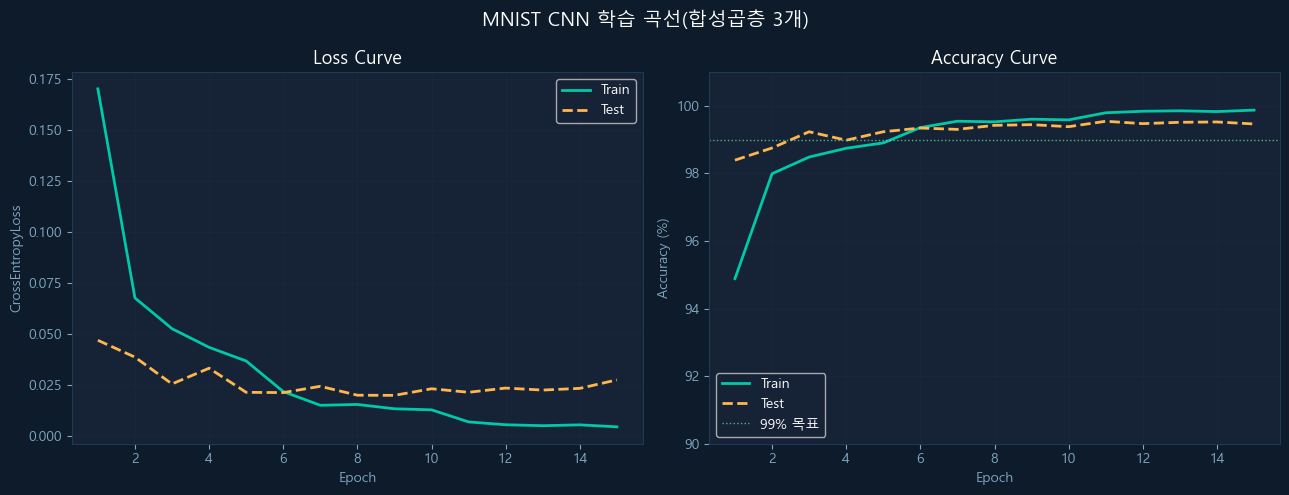

In [6]:
# 2. 중급 
# 2-1. Conv Layer를 하나 더 추가해보세요 (64→128 채널)
# CNN 모델 재정의하기 
class MnistCNN_cb3(nn.Module):
    """
    MNIST 손글씨 분류를 위한 CNN 모델
    
    Architecture:
        Conv Block 1: Conv(1→32) → BN → ReLU → MaxPool
        Conv Block 2: Conv(32→64) → BN → ReLU → MaxPool
        Conv Block 3: Conv(64→128) → BN → ReLU → MaxPool
        Classifier:   FC(1600→128) →  ReLU → Dropout → FC(128→10)
    """
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN_cb3, self).__init__()

        # ── 합성곱 블록 1 ──────────────────────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, padding=1),  # 1×28×28 → 32×28×28
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×28×28 → 32×14×14
        )

        # ── 합성곱 블록 2 ──────────────────────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),  # 32×14×14 → 64×14×14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64×14×14 → 64×7×7
        )

        # ── 합성곱 블록 3 ──────────────────────────────────────────────
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),  # 64×7×7 → 128×7×7
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128×7×7 → 128×3×3
        )

        # ── 완전연결 분류기 ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),             # 128×3×3 = 1152
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # Conv Block 1
        x = self.conv_block2(x)   # Conv Block 2
        x = self.conv_block3(x)   # Conv Block 3
        x = self.classifier(x)   # Classifier
        return x                  # raw logits (CrossEntropyLoss 사용)

    def get_feature_maps(self, x):
        """Feature Map 시각화를 위해 중간 출력 반환"""
        feat1 = self.conv_block1(x)
        feat2 = self.conv_block2(feat1)
        feat3 = self.conv_block3(feat2)
        return feat1, feat2, feat3


model = MnistCNN_cb3(dropout_rate=0.5).to(device)

# DataLoader 
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

# 에폭, 평가 함수 정의
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에폭 학습 함수."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """평가 함수. (그래디언트 계산 없음)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

# 하이퍼파라미터
NUM_EPOCHS    = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습률 스케줄러: 5 epoch마다 lr × 0.5
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'합성곱 3층 모델 학습 시작 (Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, lr: {LEARNING_RATE})')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8} | {"LR":>8}')
print('-' * 65)

best_test_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    # 최고 정확도 모델 저장
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save(model.state_dict(), 'mnist_cnn_cb3_best.pth')
        mark = ' ⭐'
    else:
        mark = ''

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{te_loss:>9.4f} | {te_acc*100:>7.2f}%{mark} | {current_lr:.6f}')

print(f'\n✅ 학습 완료!  최고 Test Accuracy: {best_test_acc*100:.2f}%')

# 학습곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
epochs = range(1, NUM_EPOCHS + 1)

for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 손실 곡선
axes[0].plot(epochs, history['train_loss'], color='#00c9a7', lw=2, label='Train')
axes[0].plot(epochs, history['test_loss'],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[0].set_title('Loss Curve', color='white', fontsize=13)
axes[0].set_ylabel('CrossEntropyLoss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')

# 정확도 곡선
axes[1].plot(epochs, [a*100 for a in history['train_acc']], color='#00c9a7', lw=2, label='Train')
axes[1].plot(epochs, [a*100 for a in history['test_acc']],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[1].axhline(y=99, color='#69f0ae', lw=1, linestyle=':', alpha=0.7, label='99% 목표')
axes[1].set_title('Accuracy Curve', color='white', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(90, 101)
axes[1].legend(facecolor='#162236', labelcolor='white')

plt.suptitle('MNIST CNN 학습 곡선(합성곱층 3개)', color='white', fontsize=14)
plt.tight_layout()
plt.show()


BatchNorm 제거 모델 학습 시작 (Epochs: 15, Batch: 64, lr: 0.001)
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     0.2243 |    93.12% |    0.0443 |   98.56% ⭐ | 0.001000
     2 |     0.0822 |    97.60% |    0.0394 |   98.62% ⭐ | 0.001000
     3 |     0.0620 |    98.16% |    0.0345 |   98.91% ⭐ | 0.001000
     4 |     0.0517 |    98.47% |    0.0278 |   99.07% ⭐ | 0.001000
     5 |     0.0440 |    98.63% |    0.0284 |   99.10% ⭐ | 0.000500
     6 |     0.0293 |    99.12% |    0.0227 |   99.42% ⭐ | 0.000500
     7 |     0.0234 |    99.28% |    0.0203 |   99.42% | 0.000500
     8 |     0.0214 |    99.33% |    0.0226 |   99.31% | 0.000500
     9 |     0.0196 |    99.41% |    0.0222 |   99.36% | 0.000500
    10 |     0.0177 |    99.48% |    0.0224 |   99.36% | 0.000250
    11 |     0.0124 |    99.58% |    0.0226 |   99.38% | 0.000250
    12 |     0.0103 |    99.65% |    0.0237 |   99.43% ⭐ | 0.000250
    1

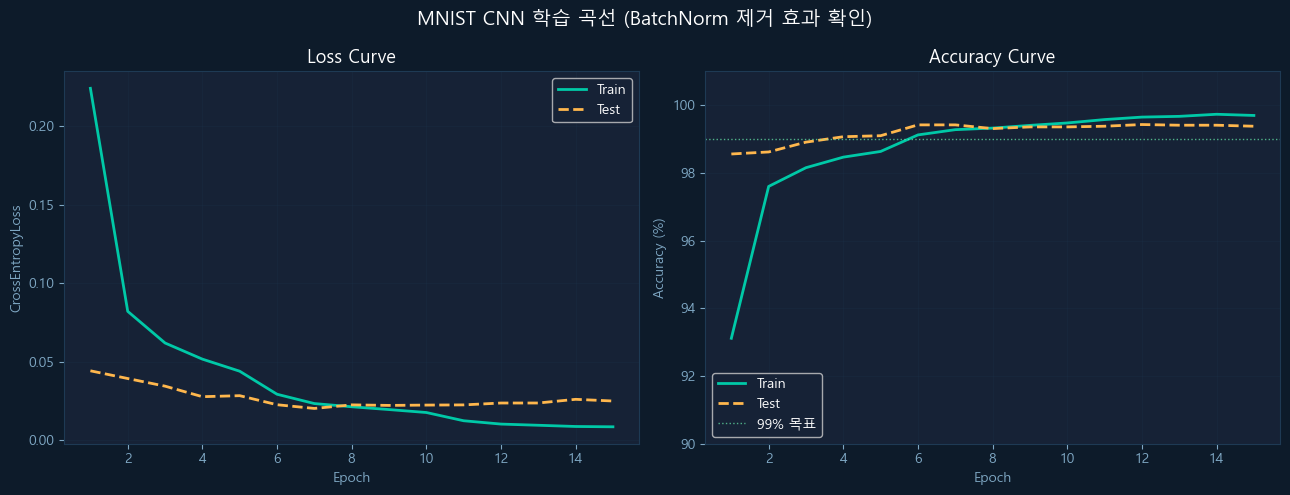

In [8]:
# 2. 중급 
# 2-2. `BatchNorm2d`를 제거했을 때 학습이 어떻게 달라지나요?
# CNN 모델 재정의하기 (BatchNorm 제거)
class MnistCNN_NoBN(nn.Module):
    """
    MNIST 손글씨 분류를 위한 CNN 모델 (BatchNorm 제거 버전)
    
    Architecture:
        Conv Block 1: Conv(1→32) → ReLU → MaxPool  (BN 제거됨)
        Conv Block 2: Conv(32→64) → ReLU → MaxPool  (BN 제거됨)
        Classifier:   FC(3136→128) → ReLU → Dropout → FC(128→10)
    """
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN_NoBN, self).__init__()

        # ── 합성곱 블록 1 (BatchNorm 제거) ─────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, padding=1),  # 1×28×28 → 32×28×28
            # nn.BatchNorm2d(32), # 💡 제거됨
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×28×28 → 32×14×14
        )

        # ── 합성곱 블록 2 (BatchNorm 제거) ─────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),  # 32×14×14 → 64×14×14
            # nn.BatchNorm2d(64), # 💡 제거됨
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64×14×14 → 64×7×7
        )

        # ── 완전연결 분류기  ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),             # 64×7×7 = 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # Conv Block 1
        x = self.conv_block2(x)   # Conv Block 2
        x = self.classifier(x)    # Classifier
        return x                  # raw logits (CrossEntropyLoss 사용)

    def get_feature_maps(self, x):
        """Feature Map 시각화를 위해 중간 출력 반환"""
        feat1 = self.conv_block1(x)
        feat2 = self.conv_block2(feat1)
        return feat1, feat2


# 💡 새로운 NoBN 모델 불러오기
model = MnistCNN_NoBN(dropout_rate=0.5).to(device)

# DataLoader 
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

# 에폭, 평가 함수 정의
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에폭 학습 함수."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """평가 함수. (그래디언트 계산 없음)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

# 하이퍼파라미터
NUM_EPOCHS    = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습률 스케줄러: 5 epoch마다 lr × 0.5
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'BatchNorm 제거 모델 학습 시작 (Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, lr: {LEARNING_RATE})')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8} | {"LR":>8}')
print('-' * 65)

best_test_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    # 최고 정확도 모델 마크
    if te_acc > best_test_acc:
        best_test_acc = te_acc
    #    torch.save(model.state_dict(), 'mnist_cnn_nobn_best.pth')
        mark = ' ⭐'
    else:
        mark = ''

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{te_loss:>9.4f} | {te_acc*100:>7.2f}%{mark} | {current_lr:.6f}')

print(f'\n✅ 학습 완료!  최고 Test Accuracy: {best_test_acc*100:.2f}%')

# 학습곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
epochs = range(1, NUM_EPOCHS + 1)

for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 손실 곡선
axes[0].plot(epochs, history['train_loss'], color='#00c9a7', lw=2, label='Train')
axes[0].plot(epochs, history['test_loss'],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[0].set_title('Loss Curve', color='white', fontsize=13)
axes[0].set_ylabel('CrossEntropyLoss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')

# 정확도 곡선
axes[1].plot(epochs, [a*100 for a in history['train_acc']], color='#00c9a7', lw=2, label='Train')
axes[1].plot(epochs, [a*100 for a in history['test_acc']],  color='#ffb74d', lw=2, label='Test', linestyle='--')
axes[1].axhline(y=99, color='#69f0ae', lw=1, linestyle=':', alpha=0.7, label='99% 목표')
axes[1].set_title('Accuracy Curve', color='white', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(90, 101) 
axes[1].legend(facecolor='#162236', labelcolor='white')

plt.suptitle('MNIST CNN 학습 곡선 (BatchNorm 제거 효과 확인)', color='white', fontsize=14)
plt.tight_layout()
plt.show()


데이터 증강(Augmentation) 모델 학습 시작 (Epochs: 15, Batch: 64)
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     0.4706 |    85.00% |    0.0477 |   98.36% ⭐ | 0.001000
     2 |     0.2440 |    92.47% |    0.0395 |   98.54% ⭐ | 0.001000
     3 |     0.2007 |    93.85% |    0.0356 |   98.69% ⭐ | 0.001000
     4 |     0.1748 |    94.70% |    0.0306 |   98.89% ⭐ | 0.001000
     5 |     0.1610 |    95.17% |    0.0282 |   99.08% ⭐ | 0.000500
     6 |     0.1250 |    96.27% |    0.0220 |   99.29% ⭐ | 0.000500
     7 |     0.1193 |    96.45% |    0.0215 |   99.28% | 0.000500
     8 |     0.1143 |    96.66% |    0.0193 |   99.34% ⭐ | 0.000500
     9 |     0.1105 |    96.80% |    0.0183 |   99.34% | 0.000500
    10 |     0.1053 |    96.86% |    0.0199 |   99.35% ⭐ | 0.000250
    11 |     0.0947 |    97.29% |    0.0184 |   99.41% ⭐ | 0.000250
    12 |     0.0913 |    97.29% |    0.0173 |   99.41% | 0.000250
    

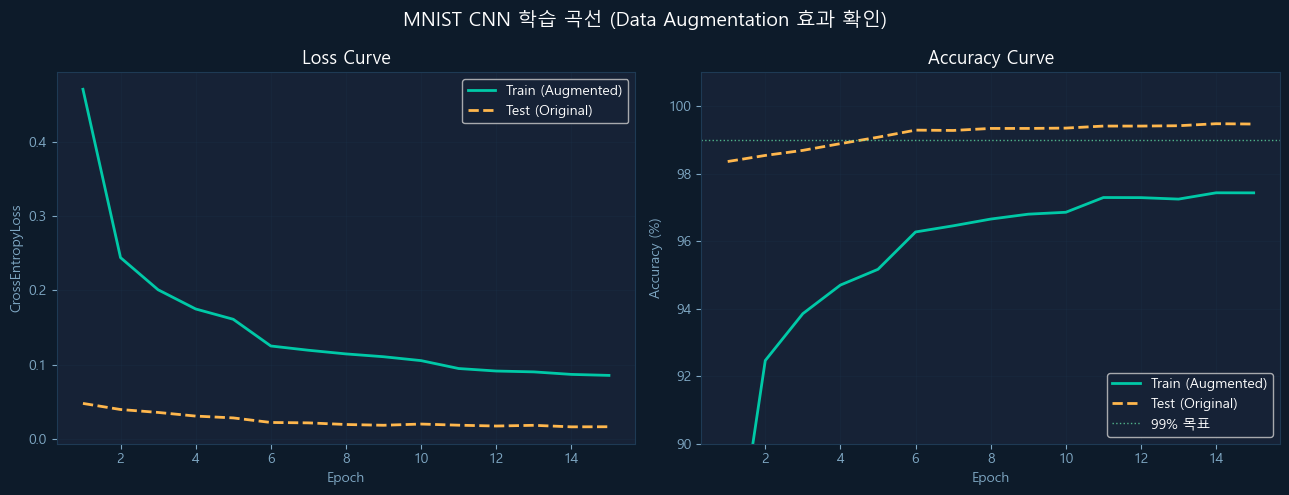

In [9]:
# 2. 중급 
# 2-3. 데이터 증강 (`RandomRotation`, `RandomAffine`)을 추가해보세요.
#─── 데이터 증강용 Transform 정의 ──────────────────────────────────────────
# 💡 훈련 데이터(Train): 회전과 이동 효과를 추가
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),                    # 무작위로 좌우 최대 15도 회전
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # 상하좌우 최대 10% 무작위 이동
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 공식 통계값(평균, 표준편차)으로 데이터 표준화
])
# 💡 테스트 데이터(Test): 평가할 때는 원본 데이터를 그대로 써야 하므로 넣지 않음
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 공식 통계값(평균, 표준편차)으로 데이터 표준화
])

# 데이터셋 불러오기 및 덮어쓰기
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

# DataLoader (원래 기본 설정인 BATCH_SIZE = 64 유지)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# ─── CNN 모델 정의  ────────────────────────────────────────────────────
class MnistCNN(nn.Module):
    """
    MNIST 손글씨 분류를 위한 CNN 모델
    
    Architecture:
        Conv Block 1: Conv(1→32) → BN → ReLU → MaxPool
        Conv Block 2: Conv(32→64) → BN → ReLU → MaxPool
        Classifier:   FC(1600→128) →  ReLU → Dropout → FC(128→10)
    """
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x
model = MnistCNN(dropout_rate=0.5).to(device)

# ─── 에폭 및 평가 함수 정의 ───────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

# ─── 학습 루프 설정 ───────────────────────────────────────────────────────
NUM_EPOCHS    = 15
LEARNING_RATE = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
print(f'데이터 증강(Augmentation) 모델 학습 시작 (Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE})')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8} | {"LR":>8}')
print('-' * 65)
best_test_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    if te_acc > best_test_acc:
        best_test_acc = te_acc
    #    torch.save(model.state_dict(), 'mnist_cnn_aug_best.pth')
        mark = ' ⭐'
    else:
        mark = ''
    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{te_loss:>9.4f} | {te_acc*100:>7.2f}%{mark} | {current_lr:.6f}')
print(f'\n✅ 데이터 증강 완료!  최고 Test Accuracy: {best_test_acc*100:.2f}%')

# ─── 학습 곡선 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
epochs = range(1, NUM_EPOCHS + 1)
for ax in axes:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')
axes[0].plot(epochs, history['train_loss'], color='#00c9a7', lw=2, label='Train (Augmented)')
axes[0].plot(epochs, history['test_loss'],  color='#ffb74d', lw=2, label='Test (Original)', linestyle='--')
axes[0].set_title('Loss Curve', color='white', fontsize=13)
axes[0].set_ylabel('CrossEntropyLoss', color='#7fa8c4')
axes[0].legend(facecolor='#162236', labelcolor='white')
axes[1].plot(epochs, [a*100 for a in history['train_acc']], color='#00c9a7', lw=2, label='Train (Augmented)')
axes[1].plot(epochs, [a*100 for a in history['test_acc']],  color='#ffb74d', lw=2, label='Test (Original)', linestyle='--')
axes[1].axhline(y=99, color='#69f0ae', lw=1, linestyle=':', alpha=0.7, label='99% 목표')
axes[1].set_title('Accuracy Curve', color='white', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', color='#7fa8c4')
axes[1].set_ylim(90, 101) 
axes[1].legend(facecolor='#162236', labelcolor='white')
plt.suptitle('MNIST CNN 학습 곡선 (Data Augmentation 효과 확인)', color='white', fontsize=14)
plt.tight_layout()
plt.show()


🚀 7-Segment (MLP) 및 MNIST (CNN) 동시 학습 시작! (Epochs: 15)
-------------------------------------------------------
 Epoch |  7-Seg Test Acc(%) |  MNIST Test Acc(%)
-------------------------------------------------------
     1 |             25.50% |             98.50%
     2 |             51.25% |             98.35%
     3 |             59.00% |             98.93%
     4 |             66.25% |             98.83%
     5 |             68.50% |             99.03%
     6 |             69.25% |             99.15%
     7 |             79.25% |             99.33%
     8 |             79.25% |             99.30%
     9 |             87.50% |             99.15%
    10 |             87.50% |             99.29%
    11 |             87.50% |             99.30%
    12 |             87.50% |             99.29%
    13 |             87.75% |             99.34%
    14 |             88.75% |             99.34%
    15 |             88.75% |             99.31%
✅ 두 모델의 학습이 성공적으로 완료되었습니다!


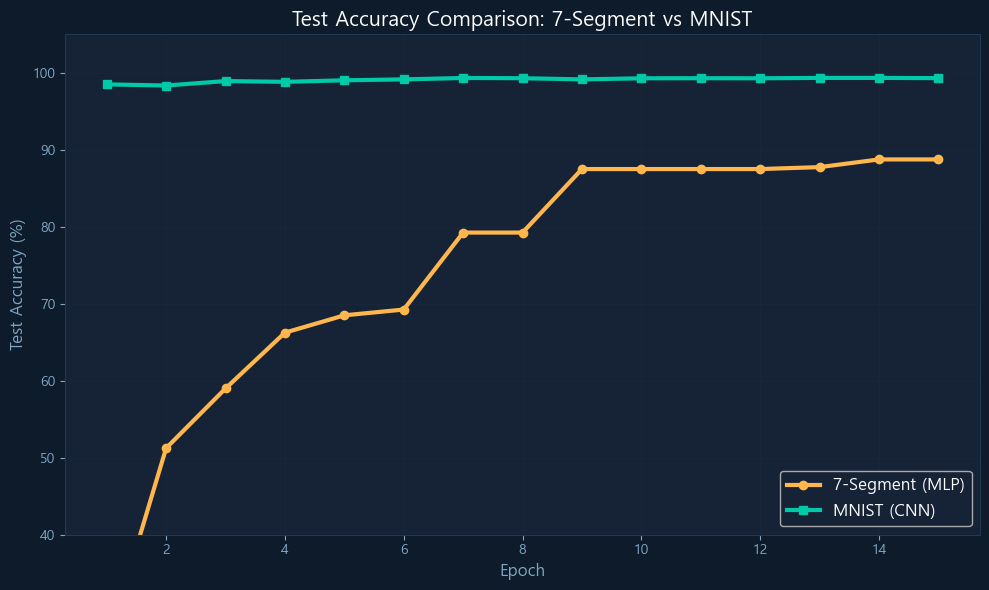


✨ 최종 결과 비교 요약 ✨
-------------------------------------------------------
1. [7-Segment MLP] 최종 정확도:  88.75%
2. [MNIST CNN]     최종 정확도:  99.31%


In [11]:
# 3. 심화
# 3-1. 7-Segment 모델과 MNIST 모델의 정확도를 같은 그래프에 그려 비교하세요.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── 7-Segment 데이터 로드 및 DataLoader 변환 ────────────────────
SEGMENTS = {
    0: [1, 1, 1, 1, 1, 1, 0], 1: [0, 1, 1, 0, 0, 0, 0], 2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1], 4: [0, 1, 1, 0, 0, 1, 1], 5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1], 7: [1, 1, 1, 0, 0, 0, 0], 8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1]
}

def augment_data(segments_dict, samples_per_class=200, noise_prob=0.05):
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            noise = np.random.binomial(1, noise_prob, size=7)
            noisy = np.array(pattern) ^ noise 
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)
    return np.array(X_list), np.array(y_list)

X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 💡 공정한 비교를 위해 7-Segment도 미니 배치(DataLoader)를 사용
train_dataset_7 = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset_7  = TensorDataset(torch.FloatTensor(X_test),  torch.LongTensor(y_test))

BATCH_SIZE = 64
train_loader_7 = DataLoader(train_dataset_7, batch_size=BATCH_SIZE, shuffle=True)
test_loader_7  = DataLoader(test_dataset_7,  batch_size=BATCH_SIZE, shuffle=False)


# ─── MNIST 데이터 로드 및 DataLoader 변환 ─────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.3081,)) 
])
train_dataset_M = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset_M  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_M = DataLoader(train_dataset_M, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader_M  = DataLoader(test_dataset_M,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# ───  모델 정의 ──────────────────────────────────────────────────
class SevenSegmentNet(nn.Module):
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), 
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)

class MnistCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

model_7 = SevenSegmentNet().to(device)
model_M = MnistCNN(dropout_rate=0.5).to(device)


# ───  공통 학습 및 평가 함수 ─────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return correct / total


# ───  두 모델 동시 학습 루프 ─────────────────────────────────────
NUM_EPOCHS = 15
criterion = nn.CrossEntropyLoss()

# 모델별 옵티마이저 (각자 파라미터를 따로 관리해야 함)
opt_7 = optim.Adam(model_7.parameters(), lr=0.001)
opt_M = optim.Adam(model_M.parameters(), lr=0.001)

history_7 = []
history_M = []

print(f"\n🚀 7-Segment (MLP) 및 MNIST (CNN) 동시 학습 시작! (Epochs: {NUM_EPOCHS})")
print('-' * 55)
print(f'{"Epoch":>6} | {"7-Seg Test Acc(%)":>18} | {"MNIST Test Acc(%)":>18}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    # 모델 7 (7-Segment) 학습 & 평가
    train_one_epoch(model_7, train_loader_7, criterion, opt_7)
    te_acc_7 = evaluate(model_7, test_loader_7)
    history_7.append(te_acc_7)
    
    # 모델 M (MNIST) 학습 & 평가
    train_one_epoch(model_M, train_loader_M, criterion, opt_M)
    te_acc_M = evaluate(model_M, test_loader_M)
    history_M.append(te_acc_M)
    
    print(f'{epoch:>6} | {te_acc_7*100:>17.2f}% | {te_acc_M*100:>17.2f}%')

print("✅ 두 모델의 학습이 성공적으로 완료되었습니다!")


# ───  하나의 그래프에 정확도 비교 시각화 ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='#7fa8c4')
for sp in ax.spines.values():
    sp.set_edgecolor('#1e3a54')
ax.grid(alpha=0.2, color='#1e3a54')

epochs_range = range(1, NUM_EPOCHS + 1)

# 두 모델의 Test Accuracy 겹쳐 그리기
ax.plot(epochs_range, [a*100 for a in history_7], color='#ffb74d', lw=3, marker='o', label='7-Segment (MLP)')
ax.plot(epochs_range, [a*100 for a in history_M], color='#00c9a7', lw=3, marker='s', label='MNIST (CNN)')

ax.set_title('Test Accuracy Comparison: 7-Segment vs MNIST', color='white', fontsize=15)
ax.set_xlabel('Epoch', color='#7fa8c4', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', color='#7fa8c4', fontsize=12)
ax.set_ylim(40, 105) # 성능 차이를 한눈에 보기 위한 Y축 설정
ax.legend(facecolor='#162236', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()


# ───  최종 결과 요약 출력 ───────────────────────────────────────
print('\n' + '='*55)
print('✨ 최종 결과 비교 요약 ✨')
print('-'*55)
print(f'1. [7-Segment MLP] 최종 정확도: {history_7[-1]*100:>6.2f}%')
print(f'2. [MNIST CNN]     최종 정확도: {history_M[-1]*100:>6.2f}%')
print('='*55)

In [ ]:
# 3. 심화
# 3-2. `torch.onnx.export()`로 모델을 ONNX 형식으로 저장해보세요.
# !pip install onnx
import os
import torch

# ─── 1. 모델 준비 및 평가 모드 ────────────────────────────────────────────
model_M.eval() 

# 💡 모델 구조를 분석하기 위해 던져주는 가짜(Dummy) 종이 텐서
# MNIST 이미지의 입력 규격에 맞게 (배치 사이즈 1, 채널 1, 세로 28, 가로 28) 만들기
dummy_input = torch.randn(1, 1, 28, 28).to(device)

onnx_file_name = "mnist_cnn_model.onnx"

print(f"🚀 PyTorch 모델을 [{onnx_file_name}] 형식으로 변환을 시작합니다...")

# ─── 2. ONNX 모델 추출(Export) ──────────────────────────────────────────
torch.onnx.export(
    model_M,                     # 저장하려는 학습 완료 모델
    dummy_input,                 # 모델의 사이즈와 구조를 파악할 수 있는 스캐닝용(?) 더미 데이터
    onnx_file_name,              # 저장될 파일의 이름
    export_params=True,          # 가중치(Weight)들까지 모두 다 담을 것인가? (True)
    opset_version=11,            # ONNX 호환성 버전 (일반적으로 11이 가장 안정적)
    do_constant_folding=True,    # 최적화 기법
    input_names=['input'],       # 입력단 이름 지정
    output_names=['output'],     # 출력단 이름 지정
    dynamic_axes={               # 배치  64장이든 128장이든 가변적으로 들어올 수 있는 동적 배치사이즈
        'input': {0: 'batch_size'}, 
        'output': {0: 'batch_size'}
    }
)

# ─── 3. 최종 결과 요약 출력 ──────────────────────────────────────────────
file_size_kb = os.path.getsize(onnx_file_name) / 1024  # 파일 용량(KB) 계산

print('\n' + '='*60)
print('✨ ONNX 모델 변환 완료 (Deployment Ready) ✨')
print('-'*60)
print(f'📍 저장 경로: {os.path.abspath(onnx_file_name)}')
print(f'📦 용량 크기: {file_size_kb:,.2f} KB')
print('🎯 활용 방안:')
print('    - 데스크탑 C++ 프로그램 연동 (ONNX Runtime)')
print('    - 스마트폰, 엣지 디바이스 등 경량화 배포 호환성 100%')
print('='*60)


   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/16.4 MB 8.4 MB/s eta 0:00:02
   -------- ------------------------------- 3.4/16.4 MB 8.8 MB/s eta 0:00:02
   -------------- ------------------------- 5.8/16.4 MB 9.5 MB/s eta 0:00:02
   ------------------ --------------------- 7.6/16.4 MB 9.4 MB/s eta 0:00:01
   ----------------------- ---------------- 9.7/16.4 MB 9.3 MB/s eta 0:00:01
   ----------------------------- ---------- 12.1/16.4 MB 9.7 MB/s eta 0:00:01
   ----------------------------------- ---- 14.4/16.4 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.4 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 10.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [protobuf]
   -------------------- ------------------- 1/2 [onnx]
   -------------------- ------------------- 1/2 [onnx]
   -------------------- ------------------- 1/2 [onnx]
   -----

100%|██████████| 26.4M/26.4M [00:45<00:00, 580kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 106kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 919kB/s] 
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]



🚀 [숫자 MNIST] vs [패션 MNIST] 동시 학습 시작! (Epochs: 15)
------------------------------------------------------------
 Epoch |    Digit Test Acc(%) |  Fashion Test Acc(%)
------------------------------------------------------------
     1 |               98.19% |               88.70%
     2 |               98.71% |               89.24%
     3 |               98.55% |               89.95%
     4 |               99.01% |               90.07%
     5 |               99.03% |               91.09%
     6 |               99.15% |               91.61%
     7 |               99.20% |               91.91%
     8 |               99.22% |               91.72%
     9 |               99.16% |               92.07%
    10 |               99.24% |               92.06%
    11 |               99.11% |               92.17%
    12 |               99.37% |               92.27%
    13 |               99.32% |               92.09%
    14 |               99.34% |               92.55%
    15 |               99.30% | 

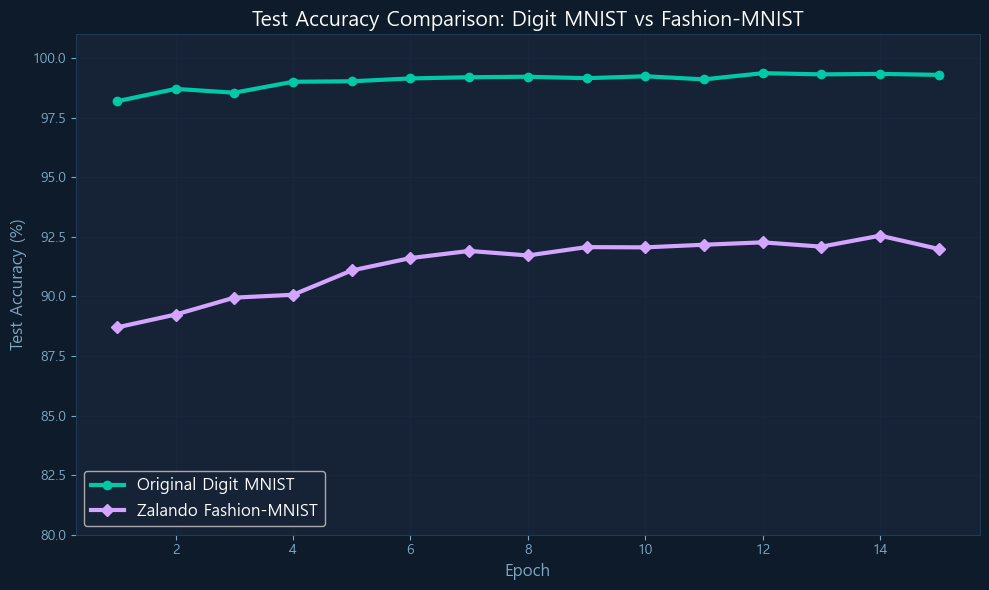


 최종 정확도 비교 요약 
-------------------------------------------------------
1. [숫자 MNIST] 최종 정확도:  99.30% (CNN 기준 매우 쉬움)
2. [패션 MNIST] 최종 정확도:  91.99% (훨씬 복잡한 패턴 요구)


In [14]:
# 3. 심화
# 3-3. Fashion-MNIST로 같은 모델을 학습하면 정확도가 어떻게 되나요?
BATCH_SIZE = 64
# ─── 1. 데이터 로드 및 DataLoader 변환 ──────────────────────────────────────
# 💡 [숫자 MNIST 데이터] 정규화 
transform_D = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,)) 
])

train_data_D = datasets.MNIST(root='./data', train=True, download=True, transform=transform_D)
test_data_D  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_D)
train_loader_D = DataLoader(train_data_D, batch_size=BATCH_SIZE, shuffle=True)
test_loader_D  = DataLoader(test_data_D,  batch_size=BATCH_SIZE, shuffle=False)

# 💡 [패션 MNIST 데이터] 정규화 
transform_F = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,)) 
])

train_data_F = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_F)
test_data_F  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_F)
train_loader_F = DataLoader(train_data_F, batch_size=BATCH_SIZE, shuffle=True)
test_loader_F  = DataLoader(test_data_F,  batch_size=BATCH_SIZE, shuffle=False)

# ─── 2. 동일한 구조의 CNN 모델 정의 ─────────────────────────────────────────
class MnistCNN(nn.Module):
    
    def __init__(self, dropout_rate=0.5):
        super(MnistCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

# 모델 준비
model_D = MnistCNN(dropout_rate=0.5).to(device) 
model_F = MnistCNN(dropout_rate=0.5).to(device) 

# ─── 3. 공통 학습 및 평가 함수 ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)
    return correct / total

# ─── 4. 동시 학습 루프 진행 ────────────────────────────────────────────────
NUM_EPOCHS = 15
criterion = nn.CrossEntropyLoss()

# 각 모델별로 가중치를 업데이트 해 줄 옵티마이저 지정
opt_D = optim.Adam(model_D.parameters(), lr=0.001)
opt_F = optim.Adam(model_F.parameters(), lr=0.001)

history_D, history_F = [], []

print(f"\n🚀 [숫자 MNIST] vs [패션 MNIST] 동시 학습 시작! (Epochs: {NUM_EPOCHS})")
print('-' * 60)
print(f'{"Epoch":>6} | {"Digit Test Acc(%)":>20} | {"Fashion Test Acc(%)":>20}')
print('-' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # 🌟 숫자 MNIST 학습
    train_one_epoch(model_D, train_loader_D, criterion, opt_D)
    te_acc_D = evaluate(model_D, test_loader_D)
    history_D.append(te_acc_D)
    
    # 🌟 패션 MNIST 학습
    train_one_epoch(model_F, train_loader_F, criterion, opt_F)
    te_acc_F = evaluate(model_F, test_loader_F)
    history_F.append(te_acc_F)
    
    print(f'{epoch:>6} | {te_acc_D*100:>19.2f}% | {te_acc_F*100:>19.2f}%')

print("\n✅ 동시 학습 완료!")

# ─── 5. 하나의 그래프에 정확도 비교 시각화 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='#7fa8c4')
for sp in ax.spines.values():
    sp.set_edgecolor('#1e3a54')
ax.grid(alpha=0.2, color='#1e3a54')
epochs_range = range(1, NUM_EPOCHS + 1)

# 두 모델의 Test Accuracy 겹쳐 그리기
ax.plot(epochs_range, [a*100 for a in history_D], color='#00c9a7', lw=3, marker='o', label='Original Digit MNIST')
ax.plot(epochs_range, [a*100 for a in history_F], color='#d4a5ff', lw=3, marker='D', label='Zalando Fashion-MNIST')
ax.set_title('Test Accuracy Comparison: Digit MNIST vs Fashion-MNIST', color='white', fontsize=15)
ax.set_xlabel('Epoch', color='#7fa8c4', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', color='#7fa8c4', fontsize=12)
ax.set_ylim(80, 101) # 성능 차이를 극적으로 보기 위한 하단 설정
ax.legend(facecolor='#162236', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

# ─── 6. 최종 결과 요약 출력 ─────────────────────────────────────────────────
print('\n' + '='*55)
print(' 최종 정확도 비교 요약 ')
print('-'*55)
print(f'1. [숫자 MNIST] 최종 정확도: {history_D[-1]*100:>6.2f}% (CNN 기준 매우 쉬움)')
print(f'2. [패션 MNIST] 최종 정확도: {history_F[-1]*100:>6.2f}% (훨씬 복잡한 패턴 요구)')
print('='*55)